<a href="https://colab.research.google.com/github/Ajb2307/Milligan_ABC-SN/blob/main_local/notebooks/ABC_data_binary_normalloss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
! pip install icecream

In [3]:
import sys
import importlib
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support, classification_report
from sklearn.utils import class_weight
from keras.utils import to_categorical
import tensorflow as tf
from tqdm.keras import TqdmCallback

sys.path.insert(0, '/content/drive/MyDrive/ABC-SN-workspace/hxetda/')
import hxetda

sys.path.insert(0, "/content/drive/MyDrive/ABC-SN-workspace/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp

sys.path.insert(0, "/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/")
from plot_data import *
from process_data import *
import heir_loss

In [4]:
import tensorflow as tf

# Get the build information dictionary
build_info = tf.sysconfig.get_build_info()

# Print the CUDA version it was built for
print("CUDA Version TensorFlow was built with:", build_info.get('cuda_version', 'Not found'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CUDA Version TensorFlow was built with: 12.5.1
Num GPUs Available:  1


In [5]:
# file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
# master_df = pd.read_parquet(file)

# data = dp.extract_dataframe(master_df)

# wvl = data[1]  # Wavelength array
# flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
# metadata = data[5]  # Sub-dataframe containing only the metadata
# all_features = data[6]  # Only the flux values in a numpy array
# fluxes0 = data[6]  # Only the flux values in a numpy array

# labels = metadata.sn_type


# this is just abcsc.training.load_data()
rng = np.random.RandomState(1415)

df_trn = pd.read_parquet("/content/drive/MyDrive/ABC-SN-workspace/ABC-SN/data/resolution_100_parquet/df_SPAR_trn.parquet")
df_tst = pd.read_parquet("/content/drive/MyDrive/ABC-SN-workspace/ABC-SN/data/resolution_100_parquet/df_SPR_tst.parquet")

# Extract the data from the files.
Xtrn, Ytrn, num_trn, num_wvl, num_classes, sn_dict_trn, wvl = dp.extract(df_trn, return_wvl=True)
Xtst, Ytst, num_tst, num_wvl, num_classes, sn_dict_tst, wvl = dp.extract(df_tst, return_wvl=True)

# Shuffle the data (This is redundant because Keras should be shuffling anyway.)
trn_shuffle_inds = rng.choice(num_trn, size=num_trn, replace=False)
tst_shuffle_inds = rng.choice(num_tst, size=num_tst, replace=False)
Xtrn = Xtrn[trn_shuffle_inds, None, :]
Xtst = Xtst[tst_shuffle_inds, None, :]

labels_trn = df_trn["SN Subtype"]
labels_tst = df_tst["SN Subtype"]


# Load data + preprocessing (hxe-tda)
### for my current code all only need pathlengths, masklist, y_dict, and weights(?)

In [6]:
conversions = {'IIP': 'CC',
               'IIb': 'CC',
               'Ia-91T':'Ia',
               'Ia-91bg':'Ia',
                'Ia-norm':'Ia',
               'Iax':'Ia',
               'Ib-norm': 'CC',
               'Ibn': 'CC',
               'Ic-broad': 'CC',
               'Ic-norm': 'CC'
       }

In [7]:
np.array(dp.extract_dataframe(df_trn)[5]["SN Subtype"].values)

array(['IIP', 'IIP', 'IIP', ..., 'Ic-norm', 'Ic-norm', 'Ic-norm'],
      dtype=object)

In [8]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

def make_dataset(master_df, load=False):
    data = dp.extract_dataframe(master_df)

    metadata = data[5]  # Sub-dataframe containing only the metadata
    flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
    all_labels = np.array(metadata["SN Subtype"].values)
    vertices =  np.asarray(np.unique(all_labels),dtype=str)
    all_flux = data[6]

    for key in conversions:
        gind = np.where(all_labels == key)
        if len(gind[0])==0:
            print(f"no labels: {key}")
        else:
            all_labels[gind] = conversions[key]

    vertices = np.asarray(np.unique(all_labels),dtype=str)
    print(np.unique(all_labels, return_counts=True))
    vertices = np.append(vertices, ["Ia"])
    vertices = np.insert(vertices, 0, 'SN')

    return(all_labels, vertices, all_flux)

labels_trn, vertices, all_features_trn = make_dataset(df_trn)
labels_tst, vertices, all_features_tst = make_dataset(df_tst)
scaler.fit(all_features_trn)
all_features = scaler.transform(all_features_trn)

(array(['CC', 'Ia'], dtype=object), array([6655, 4374]))
(array(['CC', 'Ia'], dtype=object), array([ 474, 1406]))


In [9]:
np.unique(labels_trn)

array(['CC', 'Ia'], dtype=object)

# Set up training and model

In [10]:
# # Set up for train test split...
# index = master_df.index.values
# y_mhe = np.array([y_dict[x] for x in labels]) # "multi hot encoding"
# X = fluxes0.copy()
# X = X.reshape(X.shape[0],1,X.shape[1])

# # Getting index of the train test split
# train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = labels)

# # splitting all the inputs
# X_train = X[train_index]
# X_test = X[test_index]

ohe_dict = {"Ia": [1,0],
            "CC": [0,1]}

y_trn = np.array([ohe_dict[i] for i in labels_trn])
#
y_tst = np.array([ohe_dict[i] for i in labels_tst])

In [11]:
Xtrn.shape, Xtst.shape, y_trn.shape, y_tst.shape

((11029, 1, 139), (1880, 1, 139), (11029, 2), (1880, 2))

In [12]:
np.unique(labels_trn, return_counts=True)

(array(['CC', 'Ia'], dtype=object), array([6655, 4374]))

In [13]:
y_trn.sum(axis=0)

array([4374, 6655])

# Class weights

check labels arent being scambled

make matrix in call back

print labels

In [14]:
loss_fn = keras.losses.CategoricalCrossentropy()

## Add Callbacks

In [31]:
# early stopping
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        # min_delta=1e-2, # stated during meeting (note higher than willows)
        min_delta=1e-3,
        patience= 25, # stated in meeting + same as willows
        verbose=2,
        mode="min",
        restore_best_weights=True
        )

batch_size = 64 # used below
epoch_period = 10

model_filepath = "/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/more_trunc_checkpoints/model_checkpoint{epoch}.keras" # this one creates many files
# model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint_weighted_loss.keras"
model_checkpoints = keras.callbacks.ModelCheckpoint(
    model_filepath,
    monitor="val_loss",
    verbose=0,
    save_freq = 10*len(labels_trn)// batch_size,
    mode="min",
    save_best_only=True
    )

epoch_bound = 120
step_bound = len(labels_trn) * epoch_bound // batch_size

learning_rate_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[step_bound],  # Epoch when the change happens
    values=[1e-5, 1e-6]  # Learning rates: [before boundary, after boundary]
    )

## Add New Layer to Model

In [32]:
# Loading model
abcsn = keras.models.load_model("/content/drive/MyDrive/ABC-SN-workspace/ABC-SN/abcsn/ABCSN.keras", compile=False)

In [33]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [34]:
new_model = keras.Model(
    inputs=abcsn.input,
    outputs=abcsn.layers[-2].output)

from tensorflow.keras import layers

num_labels = 2
new_output = layers.Dense(num_labels, activation="softmax", name="heirarchical_dense")(new_model.output)
heir_abcsn = keras.Model(inputs=new_model.input, outputs=new_output)

In [35]:
heir_abcsn.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 139)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1024)   │    143,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 16)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │      2,176 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_position_enco… │ (None, 64, 128)   │          0 │ dense_6[0][0]     │
│ (SinePositionEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 64)    │      8,256 │ sine_position_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │      8,320 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ dense_6[0][0],    │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │  8,389,632 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1024)      │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    262,400 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,329,538 (35.59 MB)

 Trainable params: 8,668,610 (33.07 MB)

 Non-trainable params: 660,928 (2.52 MB)

In [20]:
len(heir_abcsn.trainable_variables)

8

## Compile Model

In [36]:
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
optimizer = keras.optimizers.Nadam(learning_rate=learning_rate_schedule)

# Compile your model
heir_abcsn.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=[acc, f1]
)



# Train

In [37]:
Xtrn.shape, y_trn.shape

((11029, 1, 139), (11029, 2))

In [38]:
train = True

if train:
  history = heir_abcsn.fit(Xtrn, y_trn,
                      validation_data= (Xtst, y_tst),
                      epochs = 300,    # choosen arbitrarily
                      batch_size = 64, # same as willow used
                      verbose= 0,
                      callbacks=[TqdmCallback(verbose=1)],
                    )

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


In [24]:
# model_name = "heirarchical_truncated_model_ABC_dat_2"

# # if model was trained save the results
# if train:
#   heir_abcsn.save(f"/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/{model_name}.keras")
#   log = history.history
#   (pd.DataFrame(log)).to_csv(f"/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/{model_name}.csv")

# # if not load the results
# else:
#   heir_abcsn = keras.models.load_model(f"/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/{model_name}.keras", compile=False)
#   log = pd.read_csv(f"/content/drive/MyDrive/ABC-SN-workspace/Milligan_ABC-SN/models/{model_name}.csv")


In [39]:
log = history.history

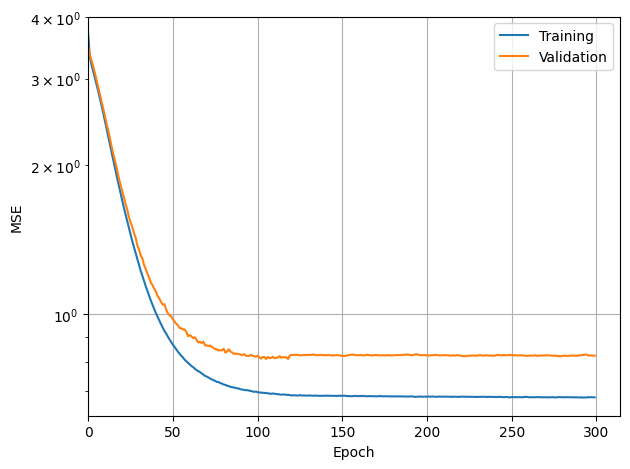

In [40]:
fig, ax = plt.subplots(1, 1)
fig.subplots_adjust(hspace=0)
ax.plot(log["loss"], c="tab:blue", label="Training")
ax.plot(log["val_loss"], c="tab:orange", label="Validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_xlim((0, None))
ax.legend(loc="upper right")
ax.grid()
ax.set_yscale("log")
fig.tight_layout()

plt.legend()
# plt.ylim(.48, .55)

# Load and Plot Model Results

In [41]:
P = heir_abcsn.predict(Xtst, verbose=0)

predict unique counts:  (array([1]), array([1880]))
true unique counts:  (array([0, 1]), array([1406,  474]))


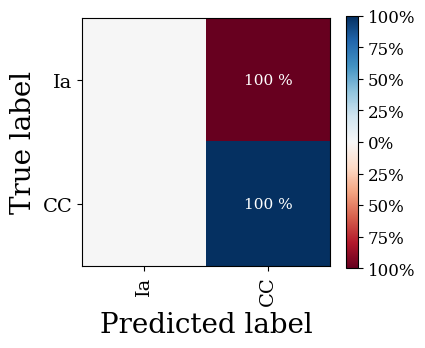

In [42]:
leaves_wanted = np.asarray(['Ia','CC'], dtype=str)
# probs_list = np.zeros((len(P), len(leaves_wanted)))
# probs_true = np.zeros((len(P), len(leaves_wanted)))
# y_pred_tensor = torch.Tensor(P)
# mask_list_tensor = torch.Tensor(mask_list)

# for i,leaf in enumerate(leaves_wanted):
#     probs_list[:,i] = hxetda.get_prob(y_pred_tensor,leaf, paths, vertices, mask_list_tensor).detach().numpy()
#     probs_true[:,i] = hxetda.get_prob(torch.Tensor(y_tst),leaf, paths, vertices, mask_list_tensor).detach().numpy()

P_argmax = np.argmax(P, axis=1)
print("predict unique counts: ",np.unique(P_argmax, return_counts = True) )
probs_list_Ia = P.copy()


y_true = np.argmax(y_tst, axis=1)
print("true unique counts: ", np.unique(y_true, return_counts = True))
y_true_Ia = y_true.copy()


cm = confusion_matrix(y_true, P_argmax)
plot = plot_cm(cm, leaves_wanted, figsize = (4,4),
        title = "")

In [49]:
np.unique(y_true, return_counts = True)

(array([0, 1]), array([1406,  474]))

So everything is getting the exact same weight so not a great start


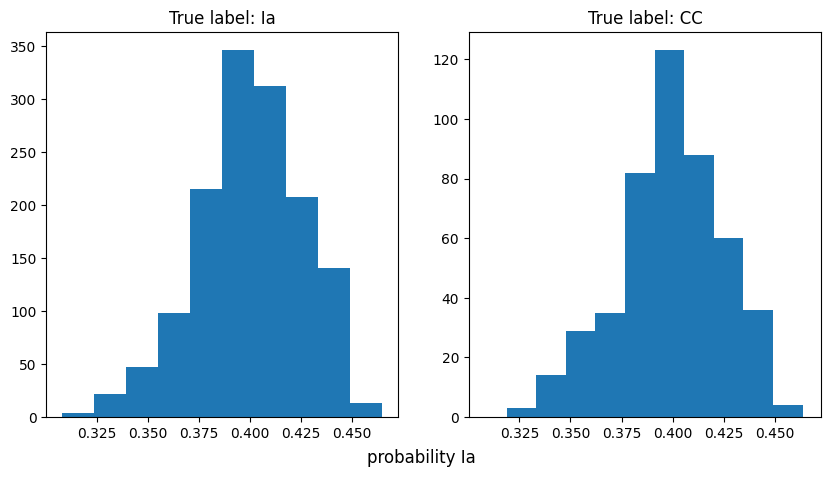

In [48]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,5))
ax[0].hist(P[:,0][y_true_Ia==0])
ax[0].set_title("True label: Ia")
ax[1].hist(P[:,0][y_true_Ia==1])
ax[1].set_title("True label: CC")
fig.supxlabel("probability Ia")
# ax[0].set_xlim((0.3,0.5))
print("So everything is getting the exact same weight so not a great start")